In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, ifft, fftfreq
from scipy.stats import kurtosis, moment
import math

## Extracción del fichero res

In [2]:
path = rf'D:\arturo_sim\simulaciones\acoplado\listado'

In [3]:
# Abrimos y extraemos la información del archivo .res
res_path = os.path.join(path,'oc4__Hs1__Tp2__dir1__1.gid','oc4__Hs1__Tp2__dir1__1.BodyKinematics.res')
with open(res_path,'rb') as res:
    res_data = res.read().decode('utf-8', errors='ignore')

In [4]:
# Escribimos la información del .res en un .txt
txt_path = os.path.join(path,'oc4__Hs1__Tp2__dir1__1.txt')

with open(txt_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(res_data)

In [5]:
# Almaceno los resultados del número de simulaciones empleado
df = pd.read_csv(txt_path, sep='\t', header=4).iloc[:,:7]

In [6]:
df

,time[s],Surge,Sway,Heave,Roll,Pitch,Yaw
0,180.0,-5.79532,3.93766,-1.28053,-0.004293,-0.089296,0.001576
1,180.1,-5.79238,3.93350,-1.28051,-0.004321,-0.089300,0.001490
2,180.2,-5.78933,3.92901,-1.28041,-0.004349,-0.089305,0.001409
3,180.3,-5.78618,3.92420,-1.28023,-0.004375,-0.089309,0.001331
4,180.4,-5.78296,3.91912,-1.27997,-0.004400,-0.089313,0.001258
...,...,...,...,...,...,...,...
10196,1199.6,-4.05517,5.11750,-1.28739,-0.004558,-0.092169,0.012928
10197,1199.7,-4.06436,5.11844,-1.28724,-0.004566,-0.092171,0.012888
10198,1199.8,-4.07366,5.11924,-1.28687,-0.004574,-0.092175,0.012848
10199,1199.9,-4.08302,5.11991,-1.28630,-0.004583,-0.092183,0.012809


## Transformada de fourier

centrar la plataforma

In [17]:
df.columns[1:]

Index(['Surge', 'Sway', 'Heave', 'Roll', 'Pitch', 'Yaw'], dtype='object')

In [18]:
for col in df.columns[1:]:
    df[col] = df[col]-df[col].mean()
df

,time[s],Surge,Sway,Heave,Roll,Pitch,Yaw
0,180.0,-1.608053,-1.131535,-0.064142,0.000343,0.003310,-0.005998
1,180.1,-1.605113,-1.135695,-0.064122,0.000315,0.003306,-0.006084
2,180.2,-1.602063,-1.140185,-0.064022,0.000287,0.003301,-0.006166
3,180.3,-1.598913,-1.144995,-0.063842,0.000261,0.003297,-0.006243
4,180.4,-1.595693,-1.150075,-0.063582,0.000236,0.003293,-0.006316
...,...,...,...,...,...,...,...
10196,1199.6,0.132097,0.048305,-0.071002,0.000078,0.000437,0.005353
10197,1199.7,0.122907,0.049245,-0.070852,0.000070,0.000435,0.005313
10198,1199.8,0.113607,0.050045,-0.070482,0.000062,0.000431,0.005274
10199,1199.9,0.104247,0.050715,-0.069912,0.000053,0.000423,0.005234


Realizamos la transformada de fourier. Es necesario transformar las columnas a vectores numpy. Podríamos hacer las FFT desde SeaFEM pero hacer eso manualmente es tedioso.

In [19]:
mov = df['Surge'].to_numpy()
time = df['time[s]'].to_numpy()

In [20]:
mov

array([-1.60805339, -1.60511339, -1.60206339, ...,  0.11360661,
        0.10424661,  0.09486661])

Text(0, 0.5, 'Amplitud')

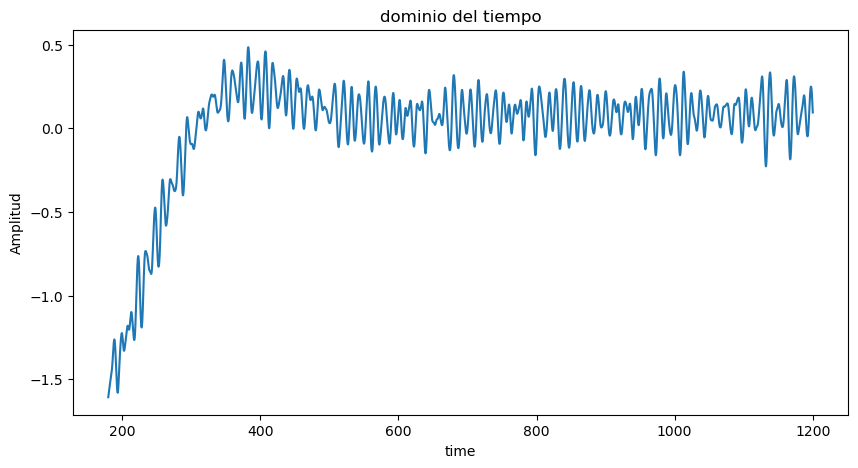

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(time, mov)
plt.title('dominio del tiempo')
plt.xlabel('time')
plt.ylabel('Amplitud')

In [22]:
fft_mov = fft(mov,norm="forward")

N=len(fft_mov)
fft_freq = fftfreq(N,0.1)[:N//2]

In [23]:
fft_freq

array([0.00000000e+00, 9.80296049e-04, 1.96059210e-03, ...,
       4.99656896e+00, 4.99754926e+00, 4.99852956e+00])

In [24]:
fft_mov

array([ 5.20229983e-16-0.j        , -9.13028205e-02+0.00987051j,
       -1.00633431e-01+0.03983422j, ..., -7.06009959e-02-0.07582489j,
       -1.00633431e-01-0.03983422j, -9.13028205e-02-0.00987051j])

In [25]:
amplitudes = 2.0/N * np.abs(fft_mov[0:N//2])

In [26]:
amplitudes

array([1.01995879e-19, 1.80050598e-05, 2.12195968e-05, ...,
       1.63310244e-08, 1.63321206e-08, 1.63297260e-08])

Text(0, 0.5, 'Amplitud')

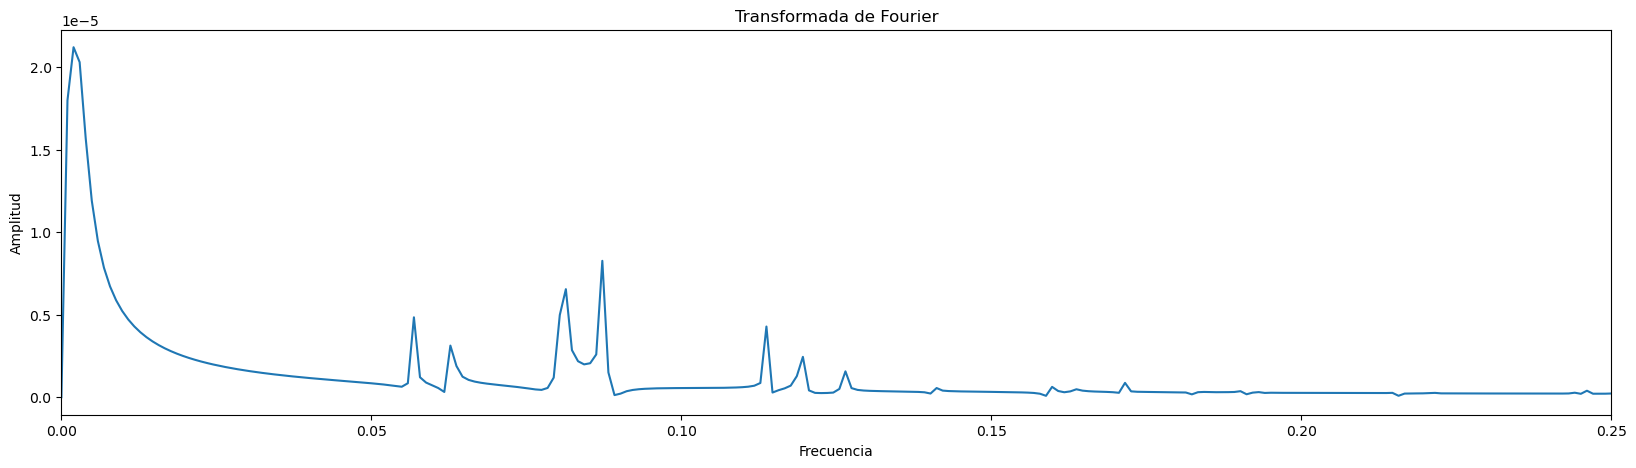

In [27]:
plt.figure(figsize=(20, 5))
plt.plot(fft_freq, amplitudes)
plt.title('Transformada de Fourier')
plt.xlim(0,0.25)
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')

In [ ]:
"""fig, [espectro_scipy,espectro_numpy]=plt.subplots(nrows=2, ncols=1)
espectro_scipy.plot(fft_freq, amplitudes)
espectro_numpy.plot(f,X_amp)"""

## Extracción de parámetros estadísticos

In [138]:
media = np.mean(amplitudes)
media

0.000999208231361845

In [140]:
desv = np.std(amplitudes)
desv

0.006783791701677136

In [147]:
kurt = kurtosis(amplitudes)
kurt

570.5680772875685

In [146]:
m0 = moment(amplitudes, moment=0)
m0

1.0

In [163]:
# organicemos un df
Hs = 1.21
Tp  = 8.15
heading = 0.0
movements = list(df.columns[1:])

In [165]:
movements

['Surge', 'Sway', 'Heave', 'Roll', 'Pitch', 'Yaw']

In [167]:
columns = ['Hs', 'Tp', 'heading'] + movements
dataset = pd.DataFrame(columns=columns)

,Hs,Tp,heading,Surge,Sway,Heave,Roll,Pitch,Yaw


La intención es que el valor de cada movimiento almacene un array con los parámetros estadísticos, ya que así nuestro dataset sería mas ligero para entrenarlo

In [168]:
time = df['time[s]'].to_numpy()

param_row = []
for mov in movements:
    mov = df[mov].to_numpy()

    # Transformada de fourier
    fft_mov = fft(mov)
    amplitudes =2/N * np.abs(fft_mov[0:N//2])
    N=len(fft_mov)
    fft_freq = fftfreq(N,0.1)[:N//2]
    
    # Parametros estadísticos
    media = np.mean(amplitudes)
    desv = np.std(amplitudes)
    kurt = kurtosis(amplitudes)
    m0 = moment(amplitudes, moment=0)

    # almacenamos en array
    array_mov = np.array([media,desv,kurt,m0])
    param_row.append(array_mov)

dataset.loc[0] = [Hs, Tp, heading] + param_row

dataset

,Hs,Tp,heading,Surge,Sway,Heave,Roll,Pitch,Yaw
0,1.21,8.15,0.0,"[0.000999208231361845, 0.006783791701677136, 5...","[0.0006787461531814014, 0.0038644641697477564,...","[6.94778883650736e-05, 0.0009693161951113076, ...","[5.508758068780339e-07, 4.380638643675336e-06,...","[2.0024358260869816e-06, 1.2442487337482168e-0...","[8.073774298175624e-06, 6.616504014832152e-05,..."


## Generación de datos con 'n' simuaciones

In [8]:
path = rf'D:\arturo_sim\simulaciones\acoplado'
dataframes = {}

# Esto hay que cambiarlo
Hs= 1.21
Tp = 4.64
heading = 90


# Abrimos y extraemos la información del archivo .res
for i in range(2,5):
    for j in range(1,6):
        for k in range(1,3):

            simulacion = f'oc4__Hs1__Tp{i}__dir{j}__{k}'
            res_path = os.path.join(path,'listado',f'{simulacion}.gid',f'{simulacion}.BodyKinematics.res')
            with open(res_path,'rb') as res:
                res_data = res.read().decode('utf-8', errors='ignore')
            
            # Escribimos la información del .res en un .txt
            txt_path = os.path.join(path,'txt',f'oc4__Hs1__Tp{i}__dir{j}__{k}.txt')
            with open(txt_path, 'w', encoding='utf-8') as txt_file:
                txt_file.write(res_data)

            # Almaceno los resultados del número de simulaciones empleado
            df = pd.read_csv(txt_path, sep='\t', header=4).iloc[:,:7]

            # Almaceno los resultados del número de simulaciones empleado
            dataframes[simulacion] = df


# Construcción del dataframe de estadísticas de los espectros de amplitud
columns = ['Hs', 'Tp', 'heading'] + movements
dataset = pd.DataFrame(columns=columns)
  
for key, df in dataframes.items():
    time = df['time[s]'].to_numpy()
    movements = list(df.columns[1:])

    # Situamos la señal a la posición de equilibrio por el error que existe al calcular Fz del flotador 
    for col in df.columns[1:]:
        df[col] = df[col]-df[col].mean()

    param_row = []
    for mov in movements:
        mov = df[mov].to_numpy()
        N=len(fft_mov)

        # Transformada de fourier
        fft_mov = fft(mov)
        amplitudes =2/N * np.abs(fft_mov[0:N//2])

        fft_freq = fftfreq(N,0.1)[:N//2]
        
        # Parametros estadísticos
        media = np.mean(amplitudes)
        desv = np.std(amplitudes)
        kurt = kurtosis(amplitudes)
        m0 = moment(amplitudes, moment=0)

        # almacenamos en array
        array_mov = np.array([media,desv,kurt,m0])
        param_row.append(array_mov)

    dataset.loc[key] = [Hs, Tp, heading] + param_row

In [9]:
dataset.reset_index(drop=True,inplace=True)

In [10]:
dataset

,Hs,Tp,heading,Surge,Sway,Heave,Roll,Pitch,Yaw
0,1.21,4.64,90,"[0.000999208231361845, 0.006783791701677136, 5...","[0.0006787461531814014, 0.0038644641697477564,...","[6.94778883650736e-05, 0.0009693161951113076, ...","[5.508758068780339e-07, 4.380638643675336e-06,...","[2.0024358260869816e-06, 1.2442487337482168e-0...","[8.073774298175624e-06, 6.616504014832152e-05,..."
1,1.21,4.64,90,"[0.001055531391100598, 0.0074652945503936785, ...","[0.0007984525604853162, 0.004911099578544964, ...","[6.950377262548584e-05, 0.0009693114652168286,...","[5.690754348356895e-07, 4.404915783269853e-06,...","[1.9993445609537904e-06, 1.24480574134488e-05,...","[9.092169843693165e-06, 7.571425916548775e-05,..."
2,1.21,4.64,90,"[0.0009896164764158265, 0.00661914653552847, 6...","[0.0007407786518921662, 0.004109541872661559, ...","[6.92642321084052e-05, 0.0009695545278544335, ...","[8.130336387476861e-07, 5.961570549755152e-06,...","[1.9789402390848344e-06, 1.1818565024974707e-0...","[7.861380619615781e-06, 6.602674598291897e-05,..."
3,1.21,4.64,90,"[0.00104636853161807, 0.00731570187197416, 691...","[0.0008609081998274719, 0.005103696377566204, ...","[6.929217748453658e-05, 0.0009695498319241189,...","[8.321229538944663e-07, 5.98071648026461e-06, ...","[1.9758071473734475e-06, 1.1824386699708063e-0...","[8.86423871108915e-06, 7.557015729374993e-05, ..."
4,1.21,4.64,90,"[0.0009617463857361079, 0.006560044236461418, ...","[0.0007961712242401823, 0.0042340471005484605,...","[7.579819216827307e-05, 0.0009887187315826729,...","[8.972341227949896e-07, 6.29253980394251e-06, ...","[1.948674731815885e-06, 1.139904465892963e-05,...","[6.364749515139403e-06, 6.180837789302372e-05,..."
5,1.21,4.64,90,"[0.0010182968004692381, 0.00726246479298669, 7...","[0.0009152105624108417, 0.005202354728601147, ...","[7.580537387179931e-05, 0.0009887137370104273,...","[9.159049149201015e-07, 6.311268316359004e-06,...","[1.9454645626374616e-06, 1.14050975231021e-05,...","[7.4242388758360695e-06, 7.19436900897632e-05,..."
6,1.21,4.64,90,"[0.0009416614300596909, 0.006605390774443679, ...","[0.0007857422009243003, 0.0041198558037543, 29...","[6.961699693541196e-05, 0.0009691552614381196,...","[8.615244960213181e-07, 5.872828030210545e-06,...","[2.1035459417156056e-06, 1.1861547957677305e-0...","[8.104551759413909e-06, 6.637929564935708e-05,..."
7,1.21,4.64,90,"[0.000998383486351244, 0.0073035206750817, 702...","[0.0009059366857959086, 0.005108817400922309, ...","[6.964312487349669e-05, 0.0009691497714027625,...","[8.802363373236368e-07, 5.893476985490164e-06,...","[2.1003311811218024e-06, 1.1867427360849247e-0...","[9.124299355691588e-06, 7.590164999264875e-05,..."
8,1.21,4.64,90,"[0.0009634008997069707, 0.006804683099245121, ...","[0.0007425346410216675, 0.003805699904303195, ...","[6.970886219418015e-05, 0.0009689032110180531,...","[6.238208615794099e-07, 4.271723658101128e-06,...","[2.3528355836419237e-06, 1.2481526010862827e-0...","[7.880986093853154e-06, 6.608124508223893e-05,..."
9,1.21,4.64,90,"[0.0010190942003449636, 0.0074845340884935815,...","[0.0008635387487399507, 0.004859014505773551, ...","[6.973446356047586e-05, 0.0009689000950523917,...","[6.429122274726668e-07, 4.300840305265983e-06,...","[2.3496880684448795e-06, 1.248716836733919e-05...","[8.882914939563873e-06, 7.561654973501942e-05,..."


TAREAS PENDIENTES
- Adaptar el código para añadir sus Hs, Tp y direccion correspondiente
- Etiquetar correctamente los casos
- representaciones de los parametros estadísticos por cada movimiento para comparar